In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler,SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,classification_report,confusion_matrix

In [3]:
driver_df=pd.read_csv(r"D:\VS_CODE\Rapido\drive-download-20260323T152350Z-3-001\cleaned_csv_files\drivers.csv")
driver_df.head()

,driver_id,driver_age,driver_city,vehicle_type,driver_experience_years,total_assigned_rides,accepted_rides,incomplete_rides,delay_count,acceptance_rate,delay_rate,avg_driver_rating,avg_pickup_delay_min,driver_delay_flag,reliability_score
0,D_000001,39,Bangalore,Auto,1,25,16,0,0,0.64,0.00,4.1,2.0,0,0.710000
1,D_000002,40,Chennai,Cab,2,14,11,3,2,0.79,0.14,4.8,6.1,1,0.717143
2,D_000003,26,Bangalore,Auto,12,19,14,3,2,0.74,0.11,4.1,2.6,1,0.681895
3,D_000004,46,Chennai,Auto,3,18,13,2,2,0.72,0.11,4.2,2.6,1,0.691111
4,D_000005,32,Chennai,Bike,7,18,16,1,1,0.89,0.06,4.8,4.9,0,0.759333


In [4]:
driver_df.columns

Index(['driver_id', 'driver_age', 'driver_city', 'vehicle_type',
       'driver_experience_years', 'total_assigned_rides', 'accepted_rides',
       'incomplete_rides', 'delay_count', 'acceptance_rate', 'delay_rate',
       'avg_driver_rating', 'avg_pickup_delay_min', 'driver_delay_flag',
       'reliability_score'],
      dtype='object')

In [5]:
bookings_df=pd.read_csv(r"drive-download-20260323T152350Z-3-001/cleaned_csv_files/bookings.csv")
bookings_df.head()

,booking_id,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,vehicle_type,...,booking_value,booking_status,incomplete_ride_reason,customer_id,driver_id,fare_per_km,fare_per_min,rush_hour_flag,long_distance_flag,city_pair
0,B_000001,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,Bike,...,148.22,Cancelled,Others,C_005097,D_004592,21.144080,3.201296,0,0,Loc_19 Loc_16
1,B_000002,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,Cab,...,465.85,Completed,Others,C_008459,D_000148,48.174767,11.018212,0,0,Loc_32 Loc_38
2,B_000003,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,Auto,...,457.03,Cancelled,Others,C_003471,D_004976,28.246601,9.413594,1,1,Loc_28 Loc_1
3,B_000004,2025-04-12,10:25:00,Saturday,1,10,Delhi,Loc_16,Loc_30,Bike,...,51.03,Completed,Others,C_002161,D_001173,50.029412,10.720588,1,0,Loc_16 Loc_30
4,B_000005,2025-08-23,00:08:00,Saturday,1,0,Hyderabad,Loc_22,Loc_31,Bike,...,144.73,Completed,Others,C_005617,D_001175,11.719028,2.242833,0,0,Loc_22 Loc_31


In [6]:
bookings_df.columns

Index(['booking_id', 'booking_date', 'booking_time', 'day_of_week',
       'is_weekend', 'hour_of_day', 'city', 'pickup_location', 'drop_location',
       'vehicle_type', 'ride_distance_km', 'estimated_ride_time_min',
       'actual_ride_time_min', 'traffic_level', 'weather_condition',
       'base_fare', 'surge_multiplier', 'booking_value', 'booking_status',
       'incomplete_ride_reason', 'customer_id', 'driver_id', 'fare_per_km',
       'fare_per_min', 'rush_hour_flag', 'long_distance_flag', 'city_pair'],
      dtype='object')

In [7]:
driver_mod_df=pd.merge(bookings_df[['driver_id','traffic_level','weather_condition','rush_hour_flag','is_weekend']],driver_df[['driver_id','vehicle_type','driver_delay_flag','reliability_score']],on='driver_id',how='left')
driver_mod_df.head()

,driver_id,traffic_level,weather_condition,rush_hour_flag,is_weekend,vehicle_type,driver_delay_flag,reliability_score
0,D_004592,High,Heavy Rain,0,0,Cab,0,0.759778
1,D_000148,Medium,Heavy Rain,0,0,Auto,0,0.730667
2,D_004976,Low,Heavy Rain,1,1,Cab,1,0.700667
3,D_001173,Medium,Rain,1,1,Cab,0,0.692000
4,D_001175,Medium,Clear,0,1,Auto,0,0.729333


In [8]:
driver_mod_df.drop('driver_id',inplace=True,axis=1)

In [9]:
driver_mod_df.columns

Index(['traffic_level', 'weather_condition', 'rush_hour_flag', 'is_weekend',
       'vehicle_type', 'driver_delay_flag', 'reliability_score'],
      dtype='object')

In [10]:
driver_mod_df.dtypes

traffic_level         object
weather_condition     object
rush_hour_flag         int64
is_weekend             int64
vehicle_type          object
driver_delay_flag      int64
reliability_score    float64
dtype: object

In [11]:
# Convert all object columns to pandas string dtype
driver_mod_df = driver_mod_df.astype({col: "string" 
                                      for col in driver_mod_df.select_dtypes(include=["object"]).columns})

# Now select categorical columns
cat_cols = driver_mod_df.select_dtypes(include=["string"]).columns.tolist()
print(cat_cols)


['traffic_level', 'weather_condition', 'vehicle_type']


In [12]:
driver_mod_df.dtypes



traffic_level        string[python]
weather_condition    string[python]
rush_hour_flag                int64
is_weekend                    int64
vehicle_type         string[python]
driver_delay_flag             int64
reliability_score           float64
dtype: object

In [13]:
driver_mod_df['driver_delay_flag'].value_counts()

driver_delay_flag
0    87453
1    12547
Name: count, dtype: int64

                          ENCODING FOR CATEGORICAL COLUMNS
                          traffic_level,weather_condition,vehicle_type


           Vehicle type

In [14]:
driver_mod_df['vehicle_type'].value_counts()

vehicle_type
Auto    33895
Cab     33744
Bike    32361
Name: count, dtype: Int64

In [15]:
ohe = OneHotEncoder(sparse_output=False)
vehicle_encoded = ohe.fit_transform(driver_mod_df[['vehicle_type']])

# Add back to DataFrame
vehicle_type_encoded_df = pd.DataFrame(vehicle_encoded, columns=ohe.get_feature_names_out(['vehicle_type']))
driver_mod_df = pd.concat([driver_mod_df, vehicle_type_encoded_df], axis=1)
driver_mod_df.head(2)

,traffic_level,weather_condition,rush_hour_flag,is_weekend,vehicle_type,driver_delay_flag,reliability_score,vehicle_type_Auto,vehicle_type_Bike,vehicle_type_Cab
0,High,Heavy Rain,0,0,Cab,0,0.759778,0.0,0.0,1.0
1,Medium,Heavy Rain,0,0,Auto,0,0.730667,1.0,0.0,0.0


                         ORDINAL ENCODING FOR TRAFFIC CONDITIONS

In [16]:
driver_mod_df['traffic_level'].value_counts()

traffic_level
High      33667
Medium    33198
Low       33135
Name: count, dtype: Int64

In [17]:
# Clean the column first (strip spaces, unify case)
driver_mod_df['traffic_level'] = driver_mod_df['traffic_level'].str.strip().str.title()

# Define encoder with explicit order
ord_encoder = OrdinalEncoder(
    categories=[['Low','Medium','High']]   
)

# Fit-transform
driver_mod_df['traffic_level'] = ord_encoder.fit_transform(
    driver_mod_df[['traffic_level']]
)


                     ONE HOT ENCODING FOR WEATHER CONDITIONS

In [18]:
driver_mod_df['weather_condition'].value_counts()

weather_condition
Heavy Rain    33616
Clear         33200
Rain          33184
Name: count, dtype: Int64

In [19]:
ohe = OneHotEncoder(sparse_output=False)

weather_encoded = ohe.fit_transform(driver_mod_df[['weather_condition']])

# Add back to DataFrame
weather_encoded_df = pd.DataFrame(weather_encoded, columns=ohe.get_feature_names_out(['weather_condition']))
driver_mod_df = pd.concat([driver_mod_df, weather_encoded_df], axis=1)
driver_mod_df.head(2)

,traffic_level,weather_condition,rush_hour_flag,is_weekend,vehicle_type,driver_delay_flag,reliability_score,vehicle_type_Auto,vehicle_type_Bike,vehicle_type_Cab,weather_condition_Clear,weather_condition_Heavy Rain,weather_condition_Rain
0,2.0,Heavy Rain,0,0,Cab,0,0.759778,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,Heavy Rain,0,0,Auto,0,0.730667,1.0,0.0,0.0,0.0,1.0,0.0


In [20]:
driver_mod_df.drop(['weather_condition','vehicle_type'],axis=1,inplace=True)

In [21]:
driver_mod_df.head(2)

,traffic_level,rush_hour_flag,is_weekend,driver_delay_flag,reliability_score,vehicle_type_Auto,vehicle_type_Bike,vehicle_type_Cab,weather_condition_Clear,weather_condition_Heavy Rain,weather_condition_Rain
0,2.0,0,0,0,0.759778,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0,0,0,0.730667,1.0,0.0,0.0,0.0,1.0,0.0


In [21]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# --- Prepare data ---
X = driver_mod_df.drop("driver_delay_flag", axis=1)   # all numeric now
y = driver_mod_df["driver_delay_flag"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- Balance training set with SMOTE ---
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced training set:", y_train_bal.value_counts())

# --- Compute class weights (optional, can skip if using SMOTE) ---
counts = y.value_counts().to_dict()
total = len(y)
n_classes = y.nunique()
class_weights = {cls: total / (n_classes * cnt) for cls, cnt in counts.items()}
print("Class weights:", class_weights)

# --- CatBoost model ---
model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_state=42,
    verbose=100,
    class_weights=class_weights   # optional with SMOTE, but can keep
)

# Fit model (no cat_features needed since all numeric)
model.fit(X_train_bal, y_train_bal, eval_set=(X_test, y_test), early_stopping_rounds=100)

# --- Predictions ---
y_train_pred = model.predict(X_train_bal)
y_test_pred = model.predict(X_test)

# --- Training metrics ---
train_acc = accuracy_score(y_train_bal, y_train_pred)
train_f1 = f1_score(y_train_bal, y_train_pred)
train_auc = roc_auc_score(y_train_bal, model.predict_proba(X_train_bal)[:,1])

print("\nTraining Metrics:")
print("Accuracy:", train_acc)
print("F1 Score:", train_f1)
print("ROC-AUC:", train_auc)

# --- Test metrics ---
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print("\nTest Metrics:")
print("Accuracy:", test_acc)
print("F1 Score:", test_f1)
print("ROC-AUC:", test_auc)

# --- Reports ---
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))


Balanced training set: driver_delay_flag
0    69962
1    69962
Name: count, dtype: int64
Class weights: {0: 0.5717356751626588, 1: 3.985016338566988}
0:	learn: 0.9330659	test: 0.6666262	best: 0.6666262 (0)	total: 155ms	remaining: 2m 34s
100:	learn: 0.9330659	test: 0.6666262	best: 0.6666262 (0)	total: 1.05s	remaining: 9.35s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6666261567
bestIteration = 0

Shrink model to first 1 iterations.

Training Metrics:
Accuracy: 0.5
F1 Score: 0.6666666666666666
ROC-AUC: 0.531476913617915

Test Metrics:
Accuracy: 0.12545
F1 Score: 0.22293304900262118
ROC-AUC: 0.53475412589915

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00     17491
           1       0.13      1.00      0.22      2509

    accuracy                           0.13     20000
   macro avg       0.06      0.50      0.11     20000
weighted avg       0.02      0.13      0.03     20000


Co

d:\VS_CODE\Rapido\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\VS_CODE\Rapido\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\VS_CODE\Rapido\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                      RANDOM FOREST CLASSIFIER

In [25]:
# --- Prepare data ---
X = driver_mod_df.drop("driver_delay_flag", axis=1)   # all numeric now
y = driver_mod_df["driver_delay_flag"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [26]:
# --- Balance training set with SMOTE ---
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Balanced training set:", y_train_bal.value_counts())


Balanced training set: driver_delay_flag
0    69962
1    69962
Name: count, dtype: int64


In [37]:
y_train_bal.shape

(139924,)

In [29]:
rf_driver_delay_model=RandomForestClassifier(random_state=77)
rf_driver_delay_model


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
rf_driver_delay_model.fit(X_train_bal,y_train_bal)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
y_pred_train=rf_driver_delay_model.predict(X_train_bal)
y_pred_test=rf_driver_delay_model.predict(X_test)


In [38]:
y_pred_train.shape

(139924,)

In [39]:
y_pred_test.shape

(20000,)

In [41]:
def performance(y,y_pred):
    accuracy=round(accuracy_score(y,y_pred)*100,2)
    print("Accuracy : ",accuracy)
    
    # F1-score (multi-class requires average)
    f1_value = round(f1_score(y, y_pred, average='weighted') * 100, 2)
    print("F1-score :", f1_value)


    
    #find roc_auc score
    y_pred_train_prob=rf_driver_delay_model.predict_proba(X_train_bal)[:, 1]
    y_pred_test_prob=rf_driver_delay_model.predict_proba(X_test)[:, 1]
  
    auc_train=roc_auc_score(y_train_bal,y_pred_train_prob,multi_class='ovr')
    auc_test=roc_auc_score(y_test,y_pred_test_prob,multi_class='ovr')

    
    print("Train AUC : ", auc_train)
    print("Test AUC : ", auc_test)
   
 
    

In [43]:
print("Training Results : \n")
performance(y_train_bal,y_pred_train)


print("\nTesting Results : \n")
performance(y_test,y_pred_test)


Training Results : 

Accuracy :  98.46
F1-score : 98.46
Train AUC :  0.9974646880206653
Test AUC :  0.859750384864559

Testing Results : 

Accuracy :  83.88
F1-score : 85.48
Train AUC :  0.9974646880206653
Test AUC :  0.859750384864559


Confusion Matrix:
 [[15049  2442]
 [  783  1726]]


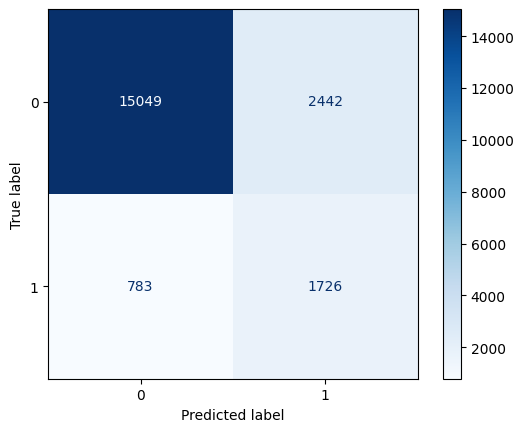

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:\n", cm)

# Optional: visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_driver_delay_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [46]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     17491
           1       0.41      0.69      0.52      2509

    accuracy                           0.84     20000
   macro avg       0.68      0.77      0.71     20000
weighted avg       0.88      0.84      0.85     20000



In [47]:
import pickle 
with open ("rf_driver_delay_model.pkl","wb") as file:
    pickle.dump(rf_driver_delay_model,file)